# ASSIGNMENT 3
### TOPIC : SPATIAL PATTERNS OF SOCIOECONOMIC VULNERABILITY IN MICHIGAN

#### PROBLEM
Socioeconomic conditions vary widely across communities and reflect underlying geographic and demographic factors. This assignment examines how selected socioeconomic indicators are distributed across Michigan. It focuses on four key measures: poverty rate, unemployment rate, housing cost burden and median household income. The main objective is to explore the spatial patterns of these indicators. Understanding these spatial patterns is essential for identifying communities that face structural disadvantages in employment opportunities, housing affordability and income.

### DATA SOURCE : MiEJScreen dataset
The assignment used data from Michigan’s environmental justice screening tool (MiEJScreen). This is an interactive mapping tool developed to identify communities that may be more vulnerable to environmental and socioeconomic stressors. The dataset contains several indicators at the census tract level for the state of Michigan.

### STEPS
1.Load the dataset to check the column names and missing values.

2.Clean and select the relevant variables [poverty rate, unemployment rate, housing cost burden, median household income]

3.Create exploratory charts (histograms) for the variables.

4.Load Michigan geographic boundary dataset (census tract level).

5.Join socioeconomic data to geographic boundaries using a common identifier.

6.Create choropleth maps for the variables to visualize their spatial distribution.


### WHY THIS DATASET?
I chose this dataset because it directly relates to my thesis on "Spatio-temporal trends of Asthma in Michigan". I would like to investigate whether communities with high asthma rates also face higher burdens of socioeconomic vulnerability. This is particularly important because indicators like poverty, unemployment, housing instability are widely recognized social conditions that influence respiratory health risks like asthma.

In [3]:
#Loading the dataset
import pandas as pd 
df = pd.read_csv('SocioEconomic_MIEJscreen.csv')
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2767 entries, 0 to 2766
Data columns (total 77 columns):
 #   Column                                                                                               Non-Null Count  Dtype  
---  ------                                                                                               --------------  -----  
 0   OBJECTID_12                                                                                          2767 non-null   int64  
 1   OBJECTID                                                                                             2767 non-null   int64  
 2   GEOID                                                                                                2767 non-null   int64  
 3   ALAND                                                                                                2767 non-null   int64  
 4   AWATER                                                                                               2767 non-null   in

In [4]:
df.columns

Index(['OBJECTID_12', 'OBJECTID', 'GEOID', 'ALAND', 'AWATER', 'NAME', 'State',
       'County', 'B01001_001', 'Shape_Leng', 'GEOID.1', 'TRACT',
       'TpopEducation', 'Education', 'EducationP', 'EducationPL',
       'PopGTE5LingIsol', 'TPopGTE5', 'LingIsolP', 'LingIsolPL', 'TPOP',
       'POVRateLT2XE', 'POVRateLT2X2P', 'POVRateLT2X2PL', 'PopCivilLabFor',
       'Unemployed', 'UnemployedP', 'UnemployedPL', 'TPopH', 'HousingE',
       'HousingEP', 'HousingEP100', 'HousingEP100PL', 'TPop2', 'WhiteAlone',
       'WhiteAloneP', 'Minorities', 'MinoritiesP', 'MinoritiesCHECK',
       'MinoritiesPL', 'Tpop#1', 'MalesLT5', 'FemalesLT5', 'TotalLT5',
       'TotalLT5P', 'TotalLT5PL', 'PopGTE65', 'PopGTE65P', 'PopGTE65PL',
       'SOCECONAve', 'SOCECONAvePLPL', 'Total Population', 'ALANDSQMi',
       'PopDenMiSq2', 'Percent Unemployed',
       'Median Household Income in past 12 months (inflation-adjusted dollars to last year of 5-year range)',
       'White alone, Not Hispanic or Latino Populat

In [5]:
#The dataset has so many columns, I need to narrow down the columns to the ones that are relevant to my analysis. 
df_trimmed = df[[ 'GEOID', 'County', 'POVRateLT2X2P','UnemployedP','HousingEP','HousingEP100','Median Household Income in past 12 months (inflation-adjusted dollars to last year of 5-year range)']]
df_trimmed.head()

,GEOID,County,POVRateLT2X2P,UnemployedP,HousingEP,HousingEP100,Median Household Income in past 12 months (inflation-adjusted dollars to last year of 5-year range)
0,26001970600,Alcona County,39.940609,16.2,0.226006,22.600619,39950.0
1,26005030200,Allegan County,11.920530,3.1,0.190359,19.035948,86007.0
2,26005030300,Allegan County,15.899151,3.4,0.146535,14.653540,73689.0
3,26005030401,Allegan County,21.892345,5.3,0.185641,18.564062,71813.0
4,26005030402,Allegan County,16.964618,6.6,0.196178,19.617763,76431.0


In [6]:
columns = {'GEOID': 'GEOID', 'County': 'County', 'POVRateLT2X2P': 'Poverty Rate', 'UnemployedP': 'Unemployment Rate', 'HousingEP': 'Housing Burdened', 'HousingEP100': 'Housing Burdened 100%', 'Median Household Income in past 12 months (inflation-adjusted dollars to last year of 5-year range)': 'Median Household Income'}
df_cleaned = df_trimmed.rename(columns=columns)
df_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 2767 entries, 0 to 2766
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   GEOID                    2767 non-null   int64  
 1   County                   2767 non-null   str    
 2   Poverty Rate             2767 non-null   float64
 3   Unemployment Rate        2746 non-null   float64
 4   Housing Burdened         2738 non-null   float64
 5   Housing Burdened 100%    2767 non-null   float64
 6   Median Household Income  2728 non-null   float64
dtypes: float64(5), int64(1), str(1)
memory usage: 151.4 KB


In [103]:
df_cleaned.describe()

,GEOID,Poverty Rate,Unemployment Rate,Housing Burdened,Housing Burdened 100%,Median Household Income
count,2.767000e+03,2767.000000,2746.000000,2738.000000,2767.000000,2728.000000
mean,2.610888e+10,34.286378,13.155717,0.298443,29.531530,59434.423387
std,4.710726e+07,19.803617,8.617299,0.119485,12.268216,27736.695064
min,2.600100e+10,0.000000,0.000000,0.000000,0.000000,7859.000000
25%,2.607501e+10,18.903917,7.400000,0.214429,21.296748,40924.500000
50%,2.612100e+10,30.673165,10.600000,0.268940,26.791621,54765.500000
75%,2.616140e+10,46.120103,16.000000,0.361619,35.909091,72339.000000
max,2.616538e+10,100.000000,66.700000,1.000000,100.000000,215417.000000


From the table, the average poverty rate is 34.29% , the average unemployment rate is 13.16%, and the average share of housing cost-burdened households is 0.298 (about 29.84% of households spending more than 30% of their income on housing). The mean median household income across tracts is $59,434 (inflation-adjusted). 

## CHARTS

### Poverty Rate :
This variable represents the percentage of the population living below 200 percent of the federal poverty level.

<Axes: title={'center': 'Distribution of Poverty Rates in Michigan'}, xlabel='Poverty Rate', ylabel='Frequency'>

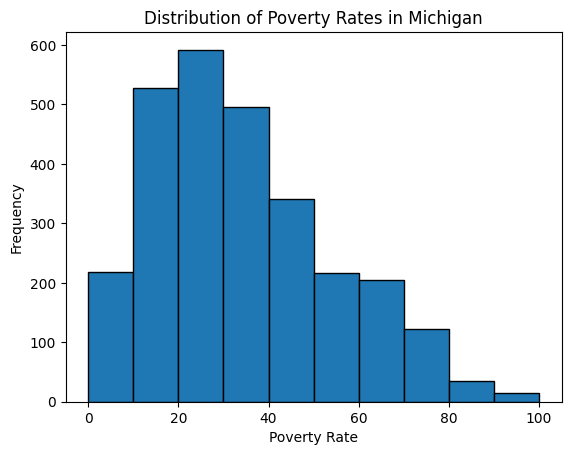

In [16]:
#Great. Now we have our dataset cleaned and ready for analysis.
import matplotlib as plot
df_cleaned['Poverty Rate'].plot(kind='hist', bins=10, edgecolor = 'black', title='Distribution of Poverty Rates in Michigan',xlabel ='Poverty Rate', ylabel = 'Frequency')

<Axes: title={'center': 'Distribution of Poverty Rates in Michigan'}, xlabel='Poverty Rate', ylabel='Frequency'>

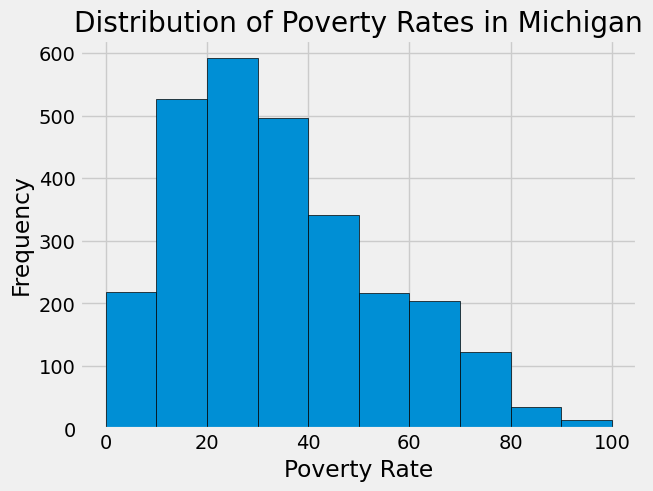

In [18]:
#Let me try another design for the histogram.
import matplotlib.pyplot as plt
figsize = (8, 10)
plt.style.use('fivethirtyeight')
df_cleaned['Poverty Rate'].plot(kind='hist', bins=10, edgecolor = 'black', title='Distribution of Poverty Rates in Michigan',xlabel ='Poverty Rate', ylabel = 'Frequency')

The histogram shows that most census tracts cluster in the low-to-moderate poverty range (roughly 10–40%), with the highest frequencies around 20–30%. The distribution is right-skewed, indicating that while some tracts experience moderate poverty rates, a small number face extreme levels (above 60%). This pattern suggests substantial spatial inequality.

### Unemployment Rate:
The unemployment rate represents the percentage of the civilian labor force aged 16 and older that is currently unemployed.

<Axes: title={'center': 'Distribution of Unemployment Rates in Michigan'}, xlabel='Unemployment Rate', ylabel='Frequency'>

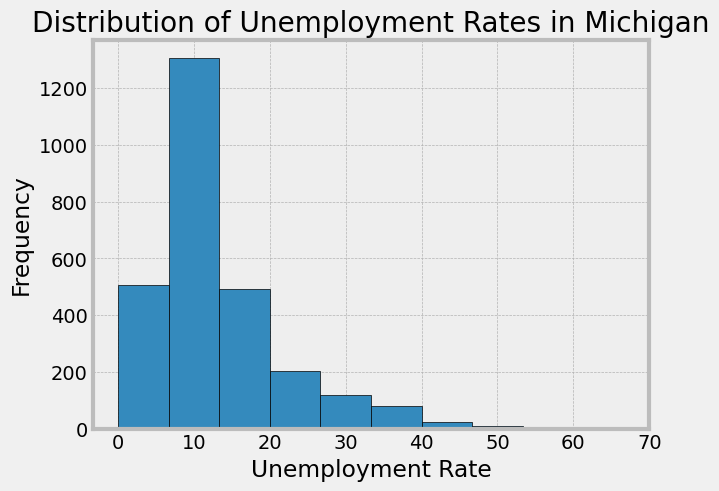

In [20]:
figsize = (8, 10)
df_cleaned['Unemployment Rate'].plot(kind='hist', bins=10, edgecolor = 'black', title='Distribution of Unemployment Rates in Michigan',xlabel ='Unemployment Rate', ylabel = 'Frequency')

The histogram indicates that most census tracts have relatively low unemployment rates, with a clear peak around 10%. The distribution is strongly right-skewed, showing that only a small number of tracts experience very high unemployment (above 30–40%).

### Housing Cost Burden:
Housing cost burden measures the percentage of households that spend more than 30 percent of their income on housing costs.

<Axes: title={'center': 'Distribution of Housing Burdened Rates in Michigan'}, xlabel='Housing Burdened Rate', ylabel='Frequency'>

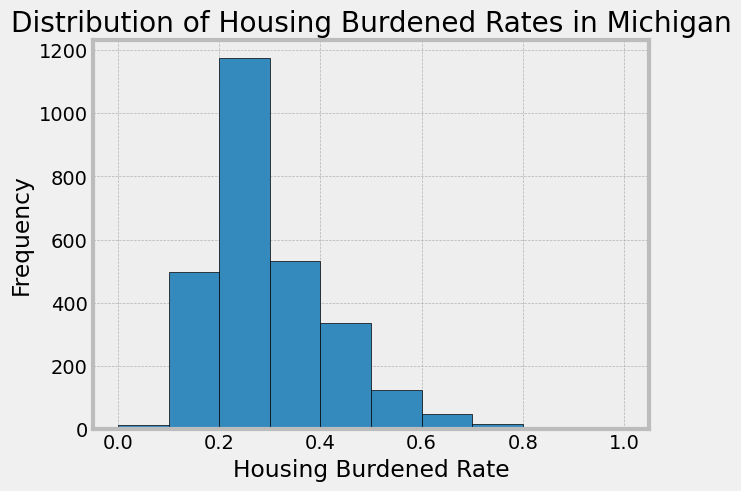

In [21]:
df_cleaned['Housing Burdened'].plot(kind='hist', bins=10, edgecolor = 'black', title='Distribution of Housing Burdened Rates in Michigan',xlabel ='Housing Burdened Rate', ylabel = 'Frequency')

<Axes: title={'center': 'Distribution of Housing Burdened [100% Rates] in Michigan'}, xlabel='Housing Burdened Rate', ylabel='Frequency'>

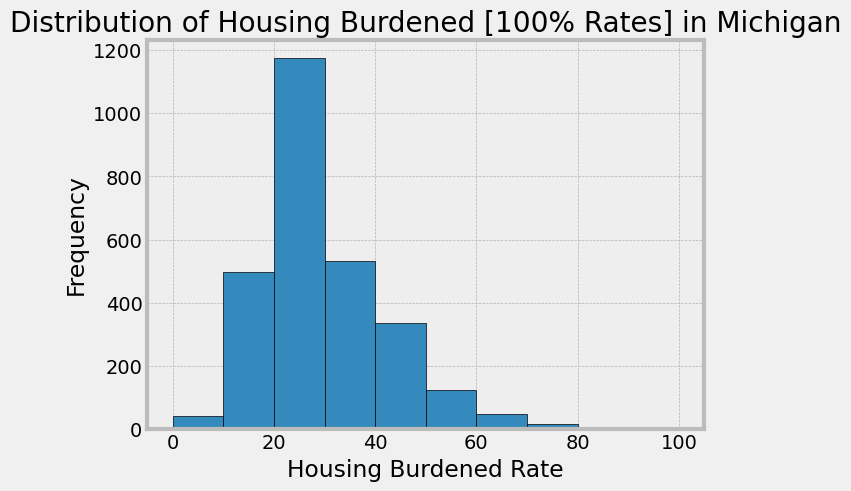

In [24]:
#The variable 'Housing Burdened 100%' is the percentage of households that are housing burdened at the 100% level.This will be easier to interpret. 
df_cleaned['Housing Burdened 100%'].plot(kind='hist', bins=10, edgecolor = 'black', title='Distribution of Housing Burdened [100% Rates] in Michigan',xlabel ='Housing Burdened Rate', ylabel = 'Frequency')

The histogram shows that most census tracts in Michigan have housing-burdened rates clustered between about 10% and 40%, with a peak around 30%. The distribution is right-skewed, indicating that fewer tracts experience very high levels of housing cost burden (above 50%).

### Median Household Income:
Median household income represents the inflation-adjusted income level (adjusted to the final year of the five-year period).

<Axes: title={'center': 'Distribution of Median Household Income in Michigan'}, xlabel='Median Household Income $', ylabel='Frequency'>

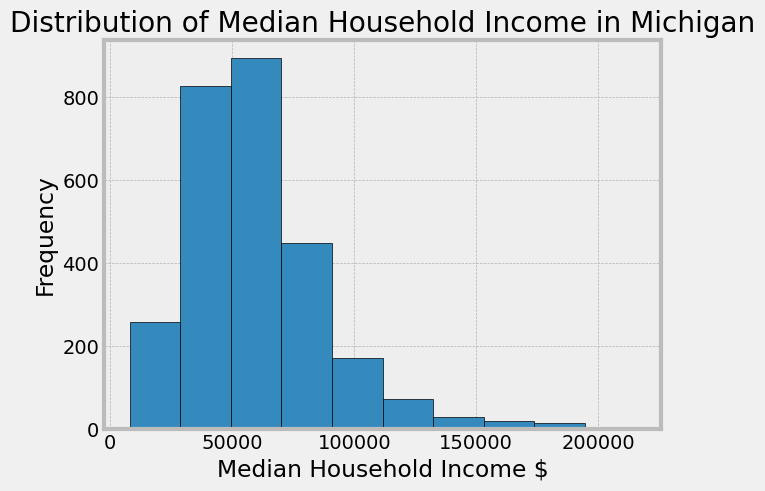

In [26]:
df_cleaned['Median Household Income'].plot(kind='hist', bins=10, edgecolor = 'black', title='Distribution of Median Household Income in Michigan',xlabel ='Median Household Income $', ylabel = 'Frequency')

The histogram shows that most census tracts in Michigan have median household incomes concentrated between roughly $40,000 and $80,000, with a peak around $50,000. The distribution is right-skewed, indicating that a smaller number of tracts have very high incomes while fewer tracts fall at the very low-income end.

## MAPS

In [27]:
import geopandas as gpd
import pandas as pd

In [28]:
df_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 2767 entries, 0 to 2766
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   GEOID                    2767 non-null   int64  
 1   County                   2767 non-null   str    
 2   Poverty Rate             2767 non-null   float64
 3   Unemployment Rate        2746 non-null   float64
 4   Housing Burdened         2738 non-null   float64
 5   Housing Burdened 100%    2767 non-null   float64
 6   Median Household Income  2728 non-null   float64
dtypes: float64(5), int64(1), str(1)
memory usage: 151.4 KB


In [ ]:
df_cleaned.head()

,GEOID,County,Poverty Rate,Unemployment Rate,Housing Burdened,Housing Burdened 100%,Median Household Income
0,26001970600,Alcona County,39.940609,16.2,0.226006,22.600619,39950.0
1,26005030200,Allegan County,11.920530,3.1,0.190359,19.035948,86007.0
2,26005030300,Allegan County,15.899151,3.4,0.146535,14.653540,73689.0
3,26005030401,Allegan County,21.892345,5.3,0.185641,18.564062,71813.0
4,26005030402,Allegan County,16.964618,6.6,0.196178,19.617763,76431.0


: 

In [9]:
df_cleaned.tail()

,GEOID,County,Poverty Rate,Unemployment Rate,Housing Burdened,Housing Burdened 100%,Median Household Income
2762,26079950400,Kalkaska County,42.007129,14.3,0.277437,27.743695,47183.0
2763,26079950602,Kalkaska County,37.723859,15.4,0.233838,23.383769,50066.0
2764,26135970300,Oscoda County,47.358370,12.2,0.330163,33.016304,37788.0
2765,26135970400,Oscoda County,42.467089,16.4,0.312277,31.227652,38017.0
2766,26135970500,Oscoda County,38.256344,13.3,0.203857,20.385675,43938.0


### Load the Michigan census tract boundaries using geodatasets/pygris

In [34]:
import geopandas as gpd
import geodatasets as gds


In [104]:
#I need to install pygris to get the shapefile for Michigan census tracts.

In [33]:
!pip install pygris


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [70]:
import pygris
michigan_tracts = pygris.tracts(state = 'MI', year = 2010)

Using FIPS code '26' for input 'MI'


Census tract boundaries from the 2010 Census were used because the MIEJScreen dataset (published in 2021) is based on 2010 tracts.

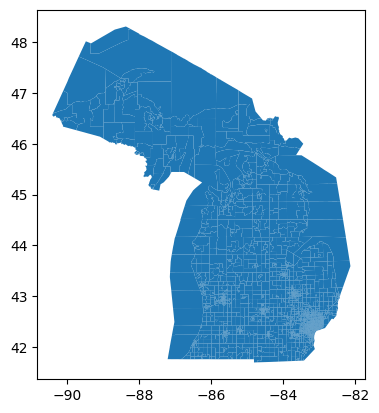

In [71]:
michigan_tracts.plot();

In [72]:
michigan_tracts.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 2813 entries, 0 to 2812
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   STATEFP10   2813 non-null   str     
 1   COUNTYFP10  2813 non-null   str     
 2   TRACTCE10   2813 non-null   str     
 3   GEOID10     2813 non-null   str     
 4   NAME10      2813 non-null   str     
 5   NAMELSAD10  2813 non-null   str     
 6   MTFCC10     2813 non-null   str     
 7   FUNCSTAT10  2813 non-null   str     
 8   ALAND10     2813 non-null   int64   
 9   AWATER10    2813 non-null   int64   
 10  INTPTLAT10  2813 non-null   str     
 11  INTPTLON10  2813 non-null   str     
 12  geometry    2813 non-null   geometry
dtypes: geometry(1), int64(2), str(10)
memory usage: 285.8 KB


In [73]:
df_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 2767 entries, 0 to 2766
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   GEOID                    2767 non-null   int64  
 1   County                   2767 non-null   str    
 2   Poverty Rate             2767 non-null   float64
 3   Unemployment Rate        2746 non-null   float64
 4   Housing Burdened         2738 non-null   float64
 5   Housing Burdened 100%    2767 non-null   float64
 6   Median Household Income  2728 non-null   float64
dtypes: float64(5), int64(1), str(1)
memory usage: 151.4 KB


In [74]:
#the GEOID column in the michigan_tracts dataset is a string, but the GEOID column in the df_cleaned dataset is an integer. I need to convert the GEOID column in the df_cleaned dataset to a string so that I can merge the two datasets.
df_cleaned.head()

,GEOID,County,Poverty Rate,Unemployment Rate,Housing Burdened,Housing Burdened 100%,Median Household Income
0,26001970600,Alcona County,39.940609,16.2,0.226006,22.600619,39950.0
1,26005030200,Allegan County,11.920530,3.1,0.190359,19.035948,86007.0
2,26005030300,Allegan County,15.899151,3.4,0.146535,14.653540,73689.0
3,26005030401,Allegan County,21.892345,5.3,0.185641,18.564062,71813.0
4,26005030402,Allegan County,16.964618,6.6,0.196178,19.617763,76431.0


In [75]:
michigan_tracts.head()

,STATEFP10,COUNTYFP10,TRACTCE10,GEOID10,NAME10,NAMELSAD10,MTFCC10,FUNCSTAT10,ALAND10,AWATER10,INTPTLAT10,INTPTLON10,geometry
0,26,111,290500,26111290500,2905,Census Tract 2905,G5020,S,20028764,5451858,+43.5849689,-084.2539377,"POLYGON ((-84.27849 43.60846, -84.27839 43.607..."
1,26,111,290700,26111290700,2907,Census Tract 2907,G5020,S,4890107,50768,+43.6170755,-084.1920233,"POLYGON ((-84.20713 43.61134, -84.20744 43.611..."
2,26,111,290800,26111290800,2908,Census Tract 2908,G5020,S,4472984,3069,+43.6340278,-084.2016894,"POLYGON ((-84.19284 43.64106, -84.18922 43.641..."
3,26,111,290900,26111290900,2909,Census Tract 2909,G5020,S,6522679,4587,+43.6475643,-084.2215974,"POLYGON ((-84.20688 43.65404, -84.20431 43.652..."
4,26,111,291000,26111291000,2910,Census Tract 2910,G5020,S,5704264,5942,+43.6464585,-084.2688725,"POLYGON ((-84.28999 43.65613, -84.28452 43.656..."


In [79]:
# Need to change the column name (GEOID10) in the michigan_tracts dataset to match the column name in the df_cleaned dataset.
michigan_tracts = michigan_tracts.rename(columns={'GEOID10': 'GEOID'})
michigan_tracts.head()

,STATEFP10,COUNTYFP10,TRACTCE10,GEOID,NAME10,NAMELSAD10,MTFCC10,FUNCSTAT10,ALAND10,AWATER10,INTPTLAT10,INTPTLON10,geometry
0,26,111,290500,26111290500,2905,Census Tract 2905,G5020,S,20028764,5451858,+43.5849689,-084.2539377,"POLYGON ((-84.27849 43.60846, -84.27839 43.607..."
1,26,111,290700,26111290700,2907,Census Tract 2907,G5020,S,4890107,50768,+43.6170755,-084.1920233,"POLYGON ((-84.20713 43.61134, -84.20744 43.611..."
2,26,111,290800,26111290800,2908,Census Tract 2908,G5020,S,4472984,3069,+43.6340278,-084.2016894,"POLYGON ((-84.19284 43.64106, -84.18922 43.641..."
3,26,111,290900,26111290900,2909,Census Tract 2909,G5020,S,6522679,4587,+43.6475643,-084.2215974,"POLYGON ((-84.20688 43.65404, -84.20431 43.652..."
4,26,111,291000,26111291000,2910,Census Tract 2910,G5020,S,5704264,5942,+43.6464585,-084.2688725,"POLYGON ((-84.28999 43.65613, -84.28452 43.656..."


In [80]:
# Let's change the integer GEOID column in df_cleaned to a string so that we can merge the two datasets.
df_format = df_cleaned.copy()
df_format['GEOID'] = df_format['GEOID'].astype(str)
df_format.info()

<class 'pandas.DataFrame'>
RangeIndex: 2767 entries, 0 to 2766
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   GEOID                    2767 non-null   str    
 1   County                   2767 non-null   str    
 2   Poverty Rate             2767 non-null   float64
 3   Unemployment Rate        2746 non-null   float64
 4   Housing Burdened         2738 non-null   float64
 5   Housing Burdened 100%    2767 non-null   float64
 6   Median Household Income  2728 non-null   float64
dtypes: float64(5), str(2)
memory usage: 151.4 KB


In [105]:
# now we can merge the two datasets.
df_merged = michigan_tracts.merge(df_format, on = 'GEOID')
df_merged.head()

,STATEFP10,COUNTYFP10,TRACTCE10,GEOID,NAME10,NAMELSAD10,MTFCC10,FUNCSTAT10,ALAND10,AWATER10,INTPTLAT10,INTPTLON10,geometry,County,Poverty Rate,Unemployment Rate,Housing Burdened,Housing Burdened 100%,Median Household Income
0,26,111,290500,26111290500,2905,Census Tract 2905,G5020,S,20028764,5451858,+43.5849689,-084.2539377,"POLYGON ((-84.27849 43.60846, -84.27839 43.607...",Midland County,12.105799,9.8,0.195291,19.529086,70959.0
1,26,111,290700,26111290700,2907,Census Tract 2907,G5020,S,4890107,50768,+43.6170755,-084.1920233,"POLYGON ((-84.20713 43.61134, -84.20744 43.611...",Midland County,26.971736,9.6,0.204348,20.434783,54821.0
2,26,111,290800,26111290800,2908,Census Tract 2908,G5020,S,4472984,3069,+43.6340278,-084.2016894,"POLYGON ((-84.19284 43.64106, -84.18922 43.641...",Midland County,11.159530,6.4,0.134070,13.407016,76780.0
3,26,111,290900,26111290900,2909,Census Tract 2909,G5020,S,6522679,4587,+43.6475643,-084.2215974,"POLYGON ((-84.20688 43.65404, -84.20431 43.652...",Midland County,17.370311,4.0,0.193390,19.339005,91200.0
4,26,111,291000,26111291000,2910,Census Tract 2910,G5020,S,5704264,5942,+43.6464585,-084.2688725,"POLYGON ((-84.28999 43.65613, -84.28452 43.656...",Midland County,21.052632,7.2,0.273676,27.367607,69920.0


In [82]:
df_merged.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 2767 entries, 0 to 2766
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   STATEFP10                2767 non-null   str     
 1   COUNTYFP10               2767 non-null   str     
 2   TRACTCE10                2767 non-null   str     
 3   GEOID                    2767 non-null   str     
 4   NAME10                   2767 non-null   str     
 5   NAMELSAD10               2767 non-null   str     
 6   MTFCC10                  2767 non-null   str     
 7   FUNCSTAT10               2767 non-null   str     
 8   ALAND10                  2767 non-null   int64   
 9   AWATER10                 2767 non-null   int64   
 10  INTPTLAT10               2767 non-null   str     
 11  INTPTLON10               2767 non-null   str     
 12  geometry                 2767 non-null   geometry
 13  County                   2767 non-null   str     
 14  

### Choropleth Map: Poverty Rate

<Axes: >

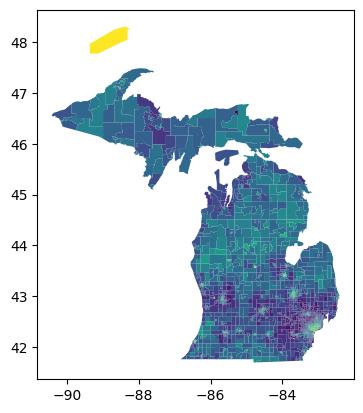

In [83]:
#Now we can create our maps.
df_merged.plot(column ='Poverty Rate')

I want to use different classification schemes.

In [86]:
!pip install mapclassify


   ---------------------------------------- 0.0/882.2 kB ? eta -:--:--
   ---------------------------------------- 882.2/882.2 kB 7.0 MB/s  0:00:00
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ----------------------------------- ---- 1.8/2.1 MB 10.9 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 9.9 MB/s  0:00:00
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ----------- ---------------------------- 2.4/8.0 MB 12.4 MB/s eta 0:00:01
   ------------------------ --------------- 5.0/8.0 MB 12.7 MB/s eta 0:00:01
   ----------------------------------- ---- 7.1/8.0 MB 11.7 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 10.9 MB/s  0:00:00
   ---------------------------------------- 0.0/36.3 MB ? eta -:--:--
   -- ------------------------------------- 2.4/36.3 MB 12.2 MB/s eta 0:00:03
   ---- ----------------------------------- 4.5/36.3 MB 11.6 MB/s eta 0:00:03
   ------- ----------------------


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


<Axes: >

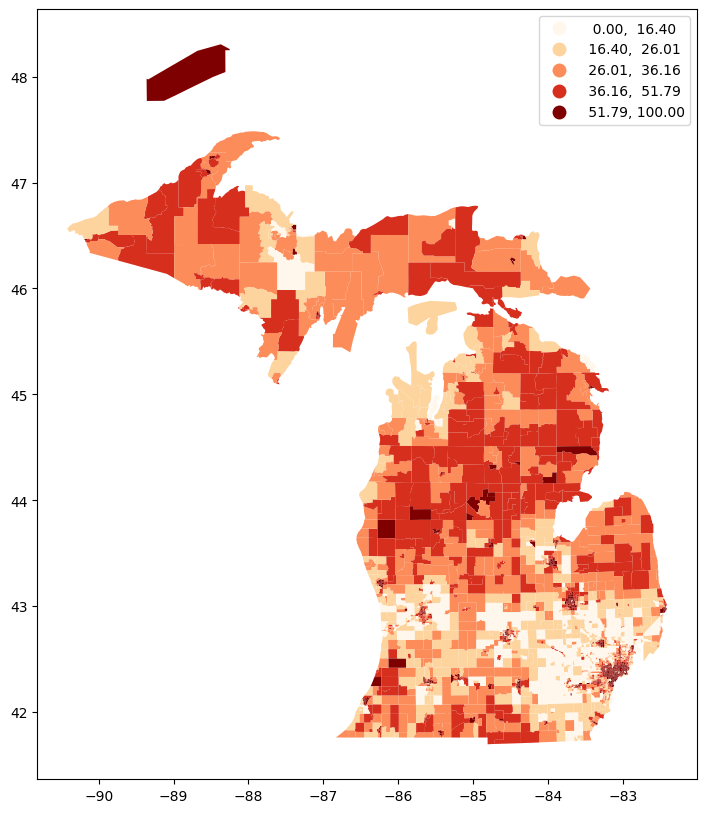

In [98]:
df_merged.plot(column='Poverty Rate', cmap = 'OrRd', scheme = 'quantiles', legend = True, figsize = (10, 10))

This map shows the share of people living below 200% of the federal poverty level across Michigan. Lighter areas indicate lower poverty rates (about 0–16.4%) and darker reds indicate higher rates (about 51.8–100%). Higher concentrations appear across parts of the Upper Peninsula and the northern/central Lower Peninsula (including parts of Southeast Michigan). Many tracts in the southern Lower Peninsula fall into the lower-to-moderate ranges.

### Unemployment Rate

<Axes: >

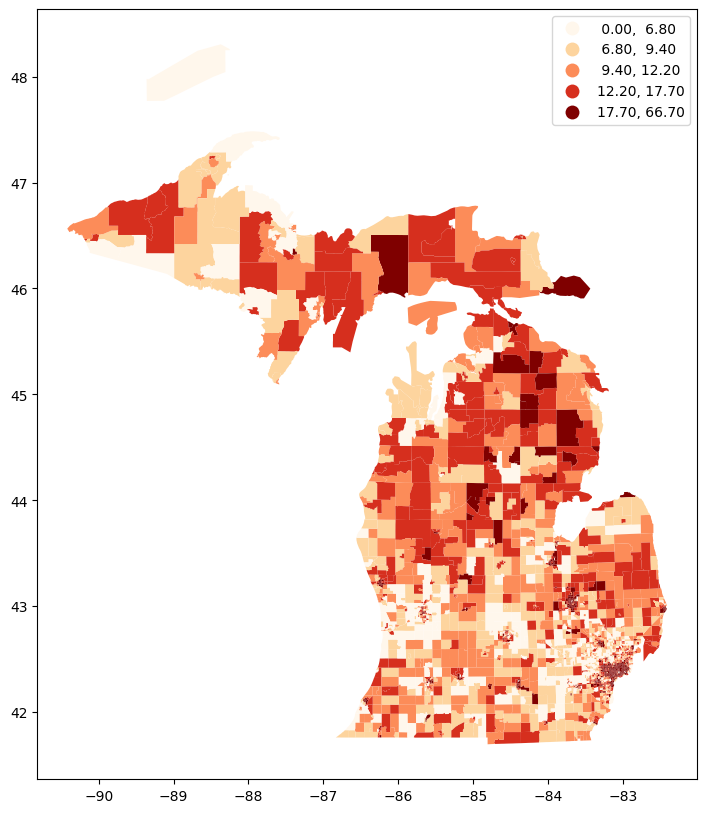

In [99]:
df_merged.plot(column='Unemployment Rate', cmap = 'OrRd', scheme = 'quantiles', legend = True, figsize = (10, 10))

This map shows unemployment rate across Michigan (the percent of the civilian labor force age 16+ that is unemployed). Lighter areas indicate lower unemployment and darker reds indicate higher unemployment. Higher unemployment rates appear across parts of the Upper Peninsula and sections of the northern/central Lower Peninsula. Additional clusters appear in  the southeast while many tracts in the southern Lower Peninsula fall into the lower to moderate categories.

### Housing Burden

<Axes: >

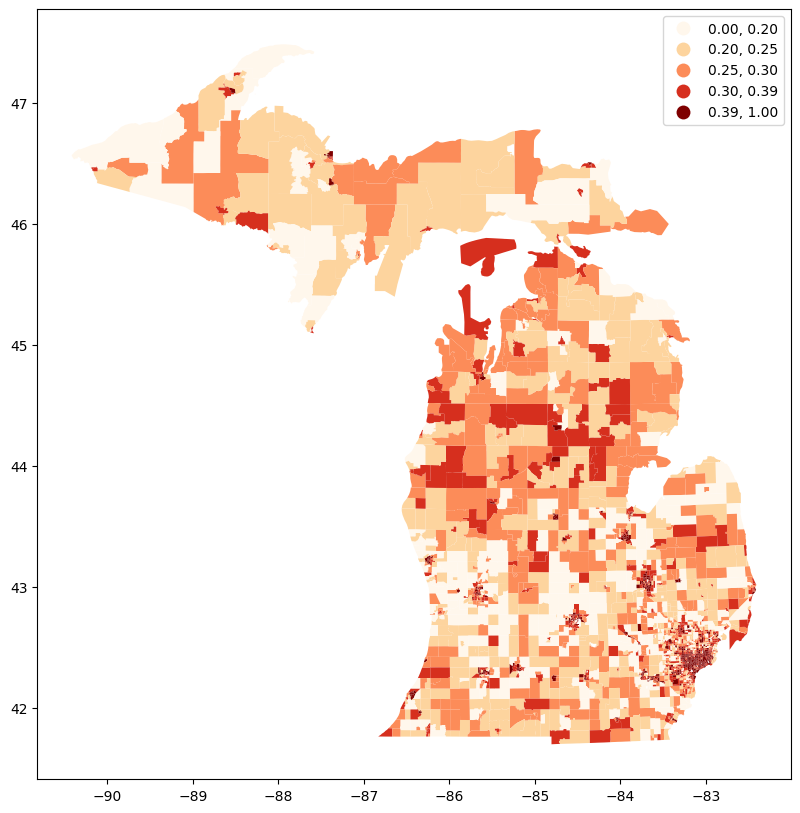

In [100]:
df_merged.plot(column='Housing Burdened', cmap = 'OrRd', scheme = 'quantiles', legend = True, figsize = (10, 10))

<Axes: >

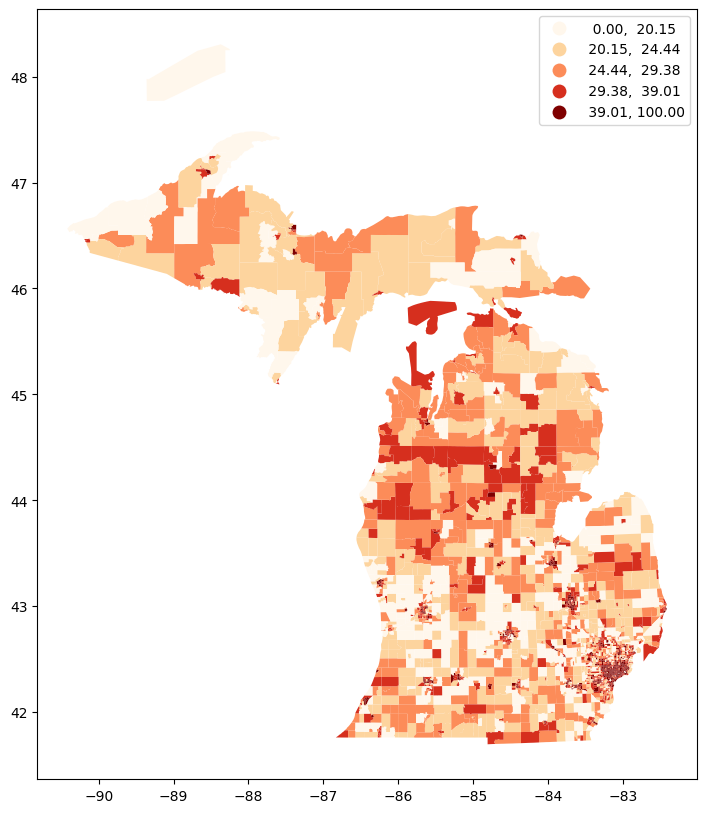

In [ ]:
# There are a lot of missing values in the  above so I would make a map for the 'Housing Burdened 100%' column to see if there are differences.
df_merged.plot(column='Housing Burdened 100%', cmap = 'OrRd', scheme = 'quantiles', legend = True, figsize = (10, 10))

These maps show the distribution of households that are housing cost-burdened in Michigan (spending more than 30% of income on housing). Lighter areas indicate lower burden while darker reds indicate higher burden. Higher housing burden clusters appear most noticeably in parts of Southeast Michigan and parts of central Michigan (the middle). 

### Median Household Income

<Axes: >

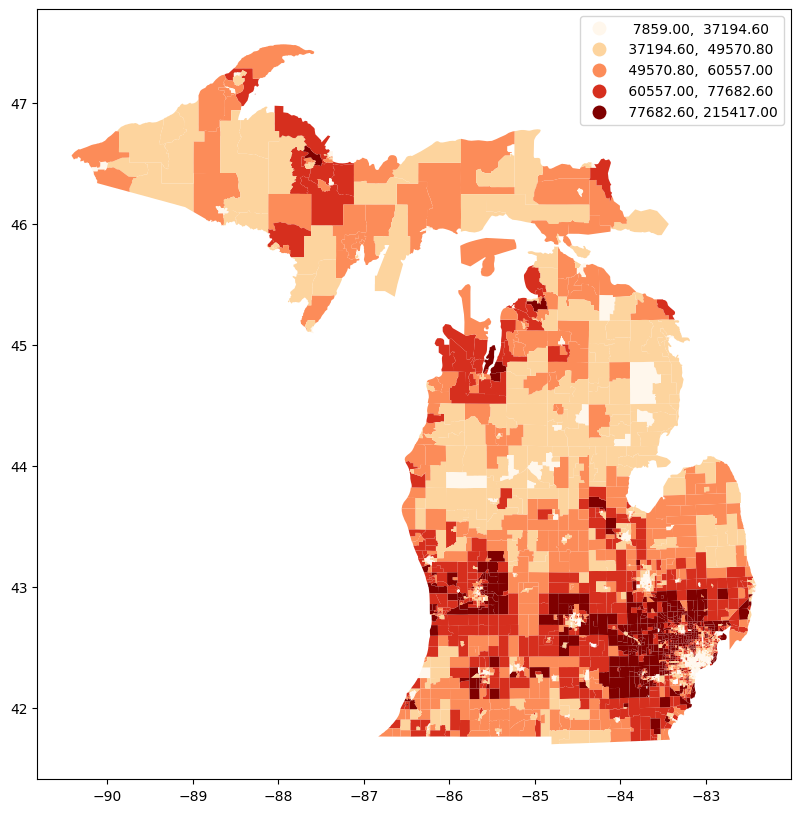

In [102]:
df_merged.plot(column='Median Household Income', cmap = 'OrRd', scheme = 'quantiles', legend = True, figsize = (10, 10))

This map shows median household income (inflation-adjusted) across Michigan, where lighter tracts represent lower incomes (about $7.9k–$37k) and darker reds represent higher incomes (about $77k–$215k). Higher-income clusters are most concentrated in Southeast Michigan while lower-income areas appear more frequently across parts of the Upper Peninsula. 

### CONCLUSION
This notebook provided an exploratory overview of the spatial distribution of multiple socioeconomic indicators across census tracts in Michigan. Detailed interpretation and discussion of these patterns will be conducted in subsequent assignments.
